# Wavelet Watermarking (Xia, Boncelet, Arce, 1998)

This notebook implements the paper **"Wavelet transform based watermark for digital images"**.

Implemented core pieces:
- DWT-domain watermark embedding (Eq. 4 in paper)
- Dynamic-range constrained reconstruction (Eq. 5 in paper)
- Hierarchical decoding via cross-correlation over offsets
- Robustness checks under additive noise, rescaling, and halftoning

> Notes:
> - Uses Haar wavelets (`pywt`), matching the paper's setup.
> - Uses a grayscale test image from `skimage.data` by default.
> - Detection is non-blind (original host image is required), matching the paper.

In [16]:
# Run this once in the notebook environment
%pip install -q numpy pywavelets scipy scikit-image matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

from scipy import signal
from skimage import io, color, transform, img_as_float

np.random.seed(42)
plt.rcParams["figure.figsize"] = (12, 4)

In [18]:
# -------------------------
# Core DWT helper utilities
# -------------------------
def dwt2_multilevel(image, levels=2, wavelet="haar"):
    return pywt.wavedec2(image, wavelet=wavelet, level=levels)


def idwt2_multilevel(coeffs, wavelet="haar"):
    return pywt.waverec2(coeffs, wavelet=wavelet)


def dynamic_range_clip(x_tilde, x_original):
    """
    Paper Eq. (5): constrain watermarked image to original min/max.
    """
    x_min = float(np.min(x_original))
    x_max = float(np.max(x_original))
    return np.clip(x_tilde, x_min, x_max)


def crop_like(arr, reference):
    r, c = reference.shape
    return arr[:r, :c]

In [19]:
# -----------------------------------
# Watermark embedding (paper Eq. 4)
# -----------------------------------
def embed_watermark_dwt(
    image,
    alpha=0.04,
    levels=2,
    wavelet="haar",
    seed=1234,
    largest_fraction=0.10,
):
    """
    y_tilde[m,n] = y[m,n] + alpha * y[m,n]^2 * N[m,n]
    applied only to the large coefficients outside the lowest-frequency LL band.
    """
    rng = np.random.default_rng(seed)
    coeffs = dwt2_multilevel(image, levels=levels, wavelet=wavelet)

    # coeffs format for 2-level: [cA2, (cH2,cV2,cD2), (cH1,cV1,cD1)]
    cA = coeffs[0]
    new_coeffs = [cA.copy()]
    watermark_noise = {}
    watermark_signal = {}
    watermark_mask = {}

    for lev_idx, detail_triplet in enumerate(coeffs[1:], start=1):
        cH, cV, cD = detail_triplet
        triplet_out = []
        for band_name, band in zip(["LH", "HL", "HH"], [cH, cV, cD]):
            N = rng.normal(loc=0.0, scale=1.0, size=band.shape)
            abs_band = np.abs(band)
            thr = np.quantile(abs_band, 1.0 - largest_fraction)
            mask = abs_band >= thr

            added = alpha * (band ** 2) * N
            band_tilde = band.copy()
            band_tilde[mask] = band_tilde[mask] + added[mask]

            triplet_out.append(band_tilde)
            watermark_noise[(lev_idx, band_name)] = N
            watermark_signal[(lev_idx, band_name)] = np.where(mask, added, 0.0)
            watermark_mask[(lev_idx, band_name)] = mask
        new_coeffs.append(tuple(triplet_out))

    x_tilde = idwt2_multilevel(new_coeffs, wavelet=wavelet)
    x_tilde = crop_like(x_tilde, image)
    x_hat = dynamic_range_clip(x_tilde, image)

    payload = {
        "levels": levels,
        "wavelet": wavelet,
        "alpha": alpha,
        "seed": seed,
        "watermark_noise": watermark_noise,
        "watermark_signal": watermark_signal,
        "watermark_mask": watermark_mask,
        "largest_fraction": largest_fraction,
    }
    return x_hat, payload

In [20]:
# -------------------------------------------------------------
# Hierarchical decoding with cross-correlation over all offsets
# -------------------------------------------------------------
def normalized_2d_xcorr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a0 = a - np.mean(a)
    b0 = b - np.mean(b)
    denom = np.linalg.norm(a0) * np.linalg.norm(b0) + 1e-12
    corr = signal.correlate2d(a0, b0, mode="full", boundary="fill", fillvalue=0)
    return corr / denom


def peak_ratio(corr_map):
    v = np.abs(corr_map).ravel()
    if v.size < 2:
        return np.inf
    idx = np.argmax(v)
    peak = v[idx]
    v[idx] = 0.0
    second = np.max(v)
    return peak / (second + 1e-12), peak


def detect_watermark_hierarchical(
    original_image,
    received_image,
    payload,
    ratio_threshold=1.05,
):
    levels = payload["levels"]
    wavelet = payload["wavelet"]
    alpha = payload["alpha"]
    Wsig = payload["watermark_signal"]

    co = dwt2_multilevel(original_image, levels=levels, wavelet=wavelet)
    cr = dwt2_multilevel(received_image, levels=levels, wavelet=wavelet)

    # Paper-like band order: start with HH1; then HH1+LH1; then HH1+LH1+HL1;
    # then continue deeper levels similarly.
    band_schedule = ["HH", "LH", "HL"]
    all_records = []

    for lev_idx in range(1, levels + 1):
        oH, oV, oD = co[lev_idx]
        rH, rV, rD = cr[lev_idx]
        band_map_o = {"LH": oH, "HL": oV, "HH": oD}
        band_map_r = {"LH": rH, "HL": rV, "HH": rD}

        selected = []
        for b in band_schedule:
            selected.append(b)
            corr_peaks = []
            for sb in selected:
                diff = band_map_r[sb] - band_map_o[sb]
                corr_map = normalized_2d_xcorr(diff, Wsig[(lev_idx, sb)])
                pr, pk = peak_ratio(corr_map)
                corr_peaks.append((pr, pk))

            ratio = float(np.mean([x[0] for x in corr_peaks]))
            peak = float(np.mean([x[1] for x in corr_peaks]))
            record = {
                "level": lev_idx,
                "bands": tuple(selected),
                "mean_peak_ratio": ratio,
                "mean_peak": peak,
                "detected": ratio >= ratio_threshold,
            }
            all_records.append(record)
            if record["detected"]:
                return True, record, all_records

    return False, None, all_records

In [21]:
# -----------------
# Attack operators
# -----------------
def add_gaussian_noise(x, sigma=0.02, seed=0):
    rng = np.random.default_rng(seed)
    y = x + rng.normal(0, sigma, x.shape)
    return np.clip(y, 0.0, 1.0)


def rescale_then_restore(x, factor=0.75, order=3):
    r, c = x.shape
    small = transform.resize(x, (int(r * factor), int(c * factor)), order=order, anti_aliasing=True)
    back = transform.resize(small, (r, c), order=order, anti_aliasing=True)
    return np.clip(back, 0.0, 1.0)


def bayer_halftone_4x4(x):
    # Threshold matrix from paper (scaled to [0,1])
    T = (1.0 / 16.0) * np.array([
        [11, 7, 10, 6],
        [3, 15, 2, 14],
        [9, 5, 12, 8],
        [1, 13, 4, 16],
    ], dtype=float)

    r, c = x.shape
    out = np.zeros_like(x)
    for i in range(r):
        for j in range(c):
            out[i, j] = 1.0 if x[i, j] >= T[i % 4, j % 4] else 0.0
    return out

In [22]:
# ----------------------
# End-to-end experiment
# ----------------------
from pathlib import Path
import json
import csv
from skimage.metrics import structural_similarity as ssim_metric

BASE_DIR = Path(".")
PY_DIR = BASE_DIR / "py"
PICTURES_DIR = BASE_DIR / "pictures"
RESULTS_DIR = BASE_DIR / "results"
for folder in (PY_DIR, PICTURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

input_image_path = PICTURES_DIR / "original.png"
if not input_image_path.exists():
    fallback = BASE_DIR / "original.png"
    if fallback.exists():
        input_image_path = fallback
    else:
        raise FileNotFoundError("Put your host image at pictures/original.png (or original.png).")

img = io.imread(str(input_image_path))

# Handle grayscale, RGB, or RGBA inputs robustly.
if img.ndim == 3:
    if img.shape[2] == 4:
        img = color.rgba2rgb(img)
    img = color.rgb2gray(img)

img = img_as_float(img)

watermarked, payload = embed_watermark_dwt(
    img,
    alpha=0.04,
    levels=2,
    wavelet="haar",
    seed=7,
    largest_fraction=0.10,
)

attacks = {
    "clean": watermarked,
    "gaussian_noise_low": add_gaussian_noise(watermarked, sigma=0.01, seed=1),
    "gaussian_noise_high": add_gaussian_noise(watermarked, sigma=0.03, seed=2),
    "rescale_75pct_restore": rescale_then_restore(watermarked, factor=0.75, order=3),
    "halftone_bayer_4x4": bayer_halftone_4x4(watermarked),
}


def mse_metric(a, b):
    return float(np.mean((a - b) ** 2))


def psnr_metric(a, b, data_range=1.0):
    mse = mse_metric(a, b)
    if mse <= 1e-15:
        return float("inf")
    return float(10.0 * np.log10((data_range ** 2) / mse))


def ncc_metric(a, b):
    a = np.asarray(a, dtype=float).ravel()
    b = np.asarray(b, dtype=float).ravel()
    a0 = a - np.mean(a)
    b0 = b - np.mean(b)
    denom = np.linalg.norm(a0) * np.linalg.norm(b0) + 1e-12
    return float(np.dot(a0, b0) / denom)


results = {}
residual_ref = watermarked - img
for name, attacked in attacks.items():
    detected, first_hit, trace = detect_watermark_hierarchical(
        original_image=img,
        received_image=attacked,
        payload=payload,
        ratio_threshold=1.05,
    )

    mse_val = mse_metric(img, attacked)
    psnr_val = psnr_metric(img, attacked, data_range=1.0)
    ssim_val = float(ssim_metric(img, attacked, data_range=1.0))
    residual_ncc = ncc_metric(residual_ref, attacked - img)

    results[name] = {
        "detected": detected,
        "first_hit": first_hit,
        "trace": trace,
        "mse": mse_val,
        "psnr_db": psnr_val,
        "ssim": ssim_val,
        "residual_ncc": residual_ncc,
    }

for k, v in results.items():
    print(f"{k:24s} detected={v['detected']}")
    if v["first_hit"] is not None:
        hit = v["first_hit"]
        print("  first hit:", f"level={hit['level']}", f"bands={hit['bands']}", f"ratio={hit['mean_peak_ratio']:.3f}")
    else:
        print("  first hit: none")

print("\nQuality metrics vs original host image (img):")
print(f"{'attack':24s} {'MSE':>12s} {'PSNR(dB)':>12s} {'SSIM':>10s} {'NCC(residual)':>15s}")
for k, v in results.items():
    psnr_str = "inf" if np.isinf(v["psnr_db"]) else f"{v['psnr_db']:.3f}"
    print(
        f"{k:24s} {v['mse']:12.6f} {psnr_str:>12s} {v['ssim']:10.4f} {v['residual_ncc']:15.4f}"
    )

# Persist outputs in project folders.
for name, arr in attacks.items():
    arr_u8 = (np.clip(arr, 0.0, 1.0) * 255.0).round().astype(np.uint8)
    io.imsave(str(PICTURES_DIR / f"{name}.png"), arr_u8)

summary_rows = []
for name, rec in results.items():
    first_hit = rec["first_hit"]
    summary_rows.append({
        "attack": name,
        "detected": rec["detected"],
        "first_hit_level": None if first_hit is None else first_hit["level"],
        "first_hit_bands": None if first_hit is None else "+".join(first_hit["bands"]),
        "first_hit_ratio": None if first_hit is None else float(first_hit["mean_peak_ratio"]),
        "mse": float(rec["mse"]),
        "psnr_db": None if np.isinf(rec["psnr_db"]) else float(rec["psnr_db"]),
        "ssim": float(rec["ssim"]),
        "residual_ncc": float(rec["residual_ncc"]),
    })

with open(RESULTS_DIR / "watermark_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, indent=2)

with open(RESULTS_DIR / "watermark_metrics.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)

with open(PY_DIR / "run_notes.txt", "w", encoding="utf-8") as f:
    f.write("Notebook run stores outputs in pictures/ and results/.\n")

print(f"\nSaved attacked images to: {PICTURES_DIR.resolve()}")
print(f"Saved metrics to: {(RESULTS_DIR / 'watermark_metrics.json').resolve()}")
print(f"Saved metrics to: {(RESULTS_DIR / 'watermark_metrics.csv').resolve()}")
print(f"Saved run note to: {(PY_DIR / 'run_notes.txt').resolve()}")

clean                    detected=True
  first hit: level=1 bands=('HH',) ratio=31.856
gaussian_noise_low       detected=True
  first hit: level=1 bands=('HH',) ratio=2.626
gaussian_noise_high      detected=True
  first hit: level=1 bands=('HH', 'LH') ratio=2.256
rescale_75pct_restore    detected=True
  first hit: level=1 bands=('HH',) ratio=1.074
halftone_bayer_4x4       detected=False
  first hit: none

Quality metrics vs original host image (img):
attack                            MSE     PSNR(dB)       SSIM   NCC(residual)
clean                        0.000001       62.329     1.0000          1.0000
gaussian_noise_low           0.000100       39.985     0.9672          0.0778
gaussian_noise_high          0.000898       30.466     0.8026          0.0226
rescale_75pct_restore        0.000578       32.384     0.9392          0.0340
halftone_bayer_4x4           0.196509        7.066     0.0547          0.0016

Saved attacked images to: C:\Users\ladha\Desktop\thesis\dwt\pictures
Saved m

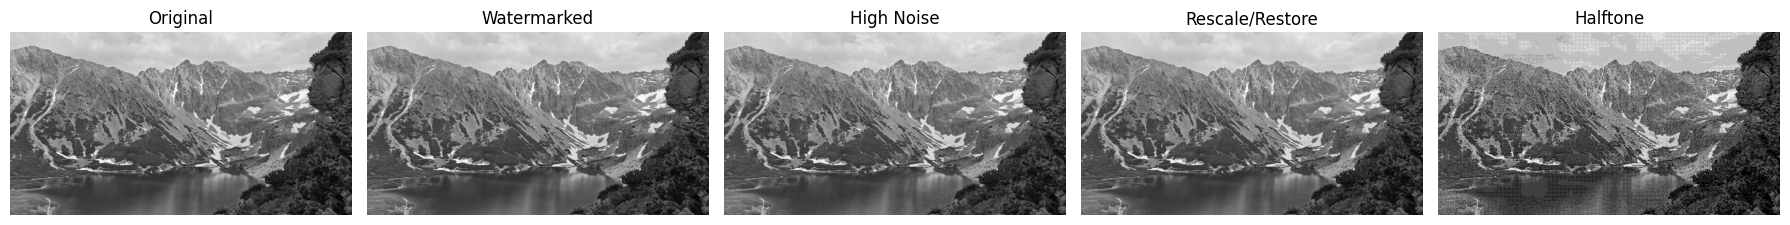

In [23]:
# Visualization
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")
ax[1].imshow(watermarked, cmap="gray")
ax[1].set_title("Watermarked")
ax[2].imshow(attacks["gaussian_noise_high"], cmap="gray")
ax[2].set_title("High Noise")
ax[3].imshow(attacks["rescale_75pct_restore"], cmap="gray")
ax[3].set_title("Rescale/Restore")
ax[4].imshow(attacks["halftone_bayer_4x4"], cmap="gray")
ax[4].set_title("Halftone")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

## Mapping to the paper

- **Eq. (4)** is implemented in `embed_watermark_dwt(...)`:
  `band_tilde = band + alpha * (band ** 2) * N`
- **Eq. (5)** is implemented in `dynamic_range_clip(...)`.
- **Hierarchical decoding** is implemented in `detect_watermark_hierarchical(...)` with band progression HH -> HH+LH -> HH+LH+HL, then deeper levels.

## Practical notes

- `alpha` controls invisibility vs robustness (bigger -> stronger watermark but more distortion).
- `ratio_threshold` controls detector strictness.
- This notebook reproduces the algorithmic idea; exact numeric matches with the paper figures depend on image choices and attack parameter details.